# Advanced Customer Segmentation using RFM Analysis

## Objective
To identify valuable customer groups using Recency, Frequency, and Monetary analysis combined with machine learning clustering techniques.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [153]:
df = pd.read_csv("../cleaned_retail.csv")

In [154]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [155]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [156]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [157]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [158]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Observation
The RFM table summarizes customer purchasing behavior using recency, order frequency, and monetary contribution.

In [159]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [160]:
rfm['CLV'] = rfm['Monetary'] / rfm['Frequency']
rfm.head()

,Recency,Frequency,Monetary,CLV
CustomerID,,,,
12346.0,326,1,77183.60,77183.600000
12347.0,2,7,4310.00,615.714286
12348.0,75,4,1797.24,449.310000
12349.0,19,1,1757.55,1757.550000
12350.0,310,1,334.40,334.400000


In [161]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [162]:
inertia = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

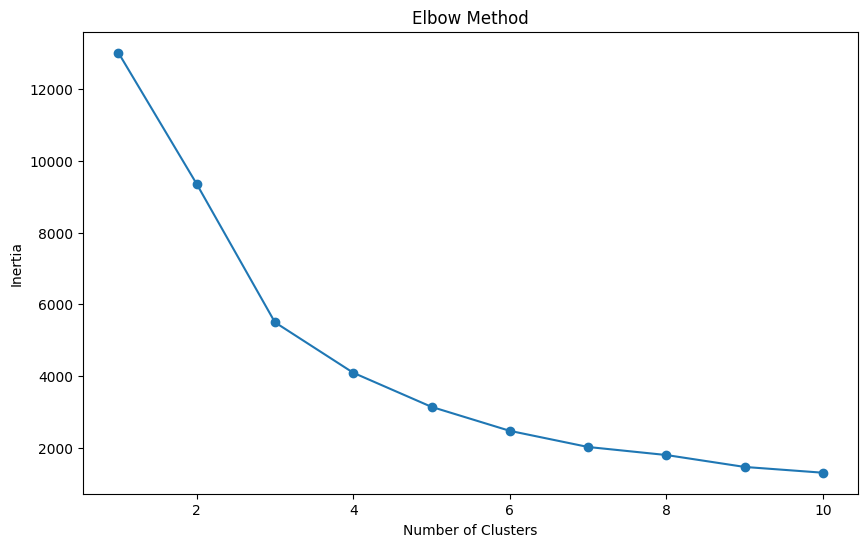

<Figure size 640x480 with 0 Axes>

In [163]:
plt.figure(figsize=(10,6))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()
plt.savefig('elbow_method')

In [164]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [165]:
rfm.head()

,Recency,Frequency,Monetary,CLV,Cluster
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,3
12347.0,2,7,4310.00,615.714286,0
12348.0,75,4,1797.24,449.310000,0
12349.0,19,1,1757.55,1757.550000,0
12350.0,310,1,334.40,334.400000,1


In [166]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,43.702685,3.682711,1359.049284,376.756939
1,248.075914,1.552015,480.617480,314.811424
2,7.384615,82.538462,127338.313846,8570.727706
3,15.500000,22.333333,12709.090490,1080.413842


In [167]:
rfm['Segment'] = rfm['Cluster'].map({
    0: 'VIP Customers',
    1: 'Lost Customers',
    2: 'Regular Customers',
    3: 'New Customers'
})
rfm.head()

,Recency,Frequency,Monetary,CLV,Cluster,Segment
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,3,New Customers
12347.0,2,7,4310.00,615.714286,0,VIP Customers
12348.0,75,4,1797.24,449.310000,0,VIP Customers
12349.0,19,1,1757.55,1757.550000,0,VIP Customers
12350.0,310,1,334.40,334.400000,1,Lost Customers


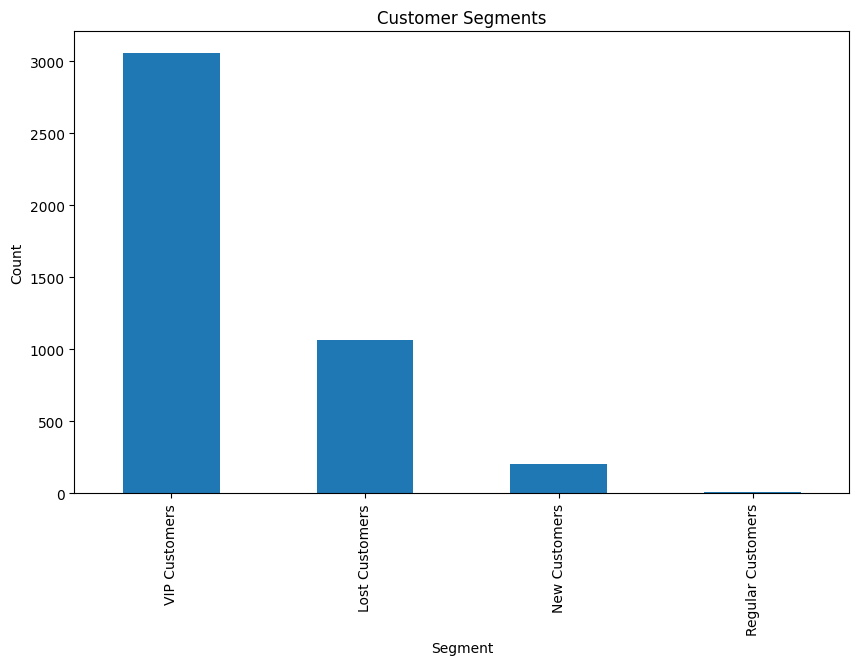

<Figure size 640x480 with 0 Axes>

In [168]:
rfm['Segment'].value_counts().plot(kind='bar', figsize=(10,6))

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Count")

plt.show()
plt.savefig('customer_segments')

In [169]:
vip_customers = rfm[rfm['Segment'] == 'VIP Customers']

vip_customers.sort_values(by='Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,CLV,Cluster,Segment
CustomerID,,,,,,
12753.0,23,6,21429.39,3571.565000,0,VIP Customers
12433.0,1,7,13375.87,1910.838571,0,VIP Customers
12477.0,23,6,13219.74,2203.290000,0,VIP Customers
14258.0,9,9,12669.98,1407.775556,0,VIP Customers
12536.0,43,3,12601.83,4200.610000,0,VIP Customers
16000.0,3,3,12393.70,4131.233333,0,VIP Customers
12557.0,16,5,11990.96,2398.192000,0,VIP Customers
12939.0,64,8,11581.80,1447.725000,0,VIP Customers
12409.0,79,3,11072.67,3690.890000,0,VIP Customers


In [ ]:
rfm.to_csv("../rfm_customer_segments.csv")

# Key Business Insights

- Customer segmentation identified multiple purchasing behavior patterns.
- VIP customers contribute significantly to overall revenue.
- Lost customers show high recency values indicating inactivity.
- CLV helps identify high-value customer groups.
- Segmentation enables personalized marketing strategies.